# 1.Introduction to Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure, characteristics, and patterns present in the dataset before building machine learning models.

The main objectives of EDA are to:

- Understand the dataset structure
- Examine the variables and their data types
- Identify missing and duplicate values
- Analyze the target variable
- Explore feature distributions
- Identify relationships between variables
- Detect potential outliers and anomalies
- Identify patterns that may be useful for sepsis prediction

*The findings from EDA will guide the data preprocessing, feature engineering, and model development stages.*

___
___

Importing necessary packages and modules

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_csv("../data/raw/raw_Dataset.csv")

___
___

# 1. Examining Dataset

In [3]:
df.shape

(1552210, 44)

___

Dataset is observed to have 1552210 rows and 44 columns.

___

In [5]:
df.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


___

Dataset is observed to have an irrelevant column "Unnamed" meaning column with no explicit name.

___

In [6]:
df = df.drop(df.columns[0], axis = 1)

In [8]:
df.head()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


___

### Dataset Dimensions

After removing the unnecessary index/`Unnamed` column, the dataset contains:

- **Number of observations (rows):** 1,552,210
- **Number of features (columns):** 43

The dataset contains clinical measurements, demographic information, ICU-related variables, time-related variables, the sepsis target variable, and a patient identifier.

___

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 43 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Hour              1552210 non-null  int64  
 1   HR                1398811 non-null  float64
 2   O2Sat             1349474 non-null  float64
 3   Temp              525226 non-null   float64
 4   SBP               1325945 non-null  float64
 5   MAP               1358940 non-null  float64
 6   DBP               1065656 non-null  float64
 7   Resp              1313875 non-null  float64
 8   EtCO2             57636 non-null    float64
 9   BaseExcess        84145 non-null    float64
 10  HCO3              65028 non-null    float64
 11  FiO2              129365 non-null   float64
 12  pH                107573 non-null   float64
 13  PaCO2             86301 non-null    float64
 14  SaO2              53561 non-null    float64
 15  AST               25183 non-null    float64
 16  BUN        

___

**Data Types**

The dataset contains 43 columns, with 38 columns stored as `float64` and 5 columns stored as `int64`. Most clinical and laboratory measurements are represented as floating-point values, while some categorical, temporal, identifier, or target variables are represented as integers.

___
___

# 3. Feature Analysis

In [11]:
df.columns

Index(['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
       'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
       'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
       'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
       'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='str')

___

## Feature Description

The dataset contains demographic information, physiological measurements, laboratory test results, hospital-related information, and the target variable used for sepsis prediction.

The main features are described below:

| Feature | Description |
|---|---|
| **Hour** | Time in hours from the beginning of the patient's ICU stay/record. |
| **HR** | Heart rate, measured in beats per minute. |
| **O2Sat** | Peripheral oxygen saturation (SpO₂), representing the percentage of hemoglobin saturated with oxygen. |
| **Temp** | Body temperature. |
| **SBP** | Systolic blood pressure, the pressure in the arteries during heart contraction. |
| **MAP** | Mean arterial pressure, an estimate of the average arterial blood pressure. |
| **DBP** | Diastolic blood pressure, the pressure in the arteries when the heart relaxes. |
| **Resp** | Respiratory rate, representing the number of breaths per minute. |
| **EtCO2** | End-tidal carbon dioxide, the concentration of CO₂ at the end of exhalation. |
| **BaseExcess** | Base excess, a measure used to assess the metabolic component of acid-base balance. |
| **HCO3** | Bicarbonate concentration in the blood, an important component of acid-base regulation. |
| **FiO2** | Fraction of inspired oxygen, representing the concentration of oxygen being inhaled. |
| **pH** | Blood pH, indicating the acidity or alkalinity of the blood. |
| **PaCO2** | Partial pressure of carbon dioxide in arterial blood. |
| **SaO2** | Arterial oxygen saturation. |
| **AST** | Aspartate aminotransferase, an enzyme commonly measured to assess tissue/liver injury. |
| **BUN** | Blood urea nitrogen, a measurement related to kidney function and protein metabolism. |
| **Alkalinephos** | Alkaline phosphatase, an enzyme associated mainly with the liver, bile ducts, and bones. |
| **Calcium** | Concentration of calcium in the blood. |
| **Chloride** | Concentration of chloride ions in the blood. |
| **Creatinine** | Blood creatinine level, commonly used as an indicator of kidney function. |
| **Bilirubin_direct** | Direct (conjugated) bilirubin concentration. |
| **Glucose** | Blood glucose concentration. |
| **Lactate** | Blood lactate concentration, which can provide information about tissue oxygenation and metabolic stress. |
| **Magnesium** | Concentration of magnesium in the blood. |
| **Phosphate** | Concentration of phosphate in the blood. |
| **Potassium** | Concentration of potassium in the blood. |
| **Bilirubin_total** | Total bilirubin concentration in the blood. |
| **TroponinI** | Troponin I level, a biomarker associated with cardiac muscle injury. |
| **Hct** | Hematocrit, the proportion of blood volume occupied by red blood cells. |
| **Hgb** | Hemoglobin concentration in the blood. |
| **PTT** | Partial thromboplastin time, a measure of blood coagulation. |
| **WBC** | White blood cell count, an important measure related to immune response and infection. |
| **Fibrinogen** | A blood-clotting protein involved in coagulation. |
| **Platelets** | Platelet count, representing the number of platelets in the blood. |
| **Age** | Age of the patient. |
| **Gender** | Patient's recorded gender. |
| **Unit1** | Indicator for the patient's ICU unit type/location, where available. |
| **Unit2** | Indicator for another ICU unit type/location, where available. |
| **HospAdmTime** | Time interval between hospital admission and the current record. |
| **ICULOS** | ICU length of stay, measured in hours from ICU admission. |
| **SepsisLabel** | Target variable indicating whether the patient meets the dataset's sepsis labeling criteria at that time point. |
| **Patient_ID** | Identifier used to distinguish individual patients. |

### Feature Categories

For easier analysis, the variables can be grouped into the following categories:

**Time-related features**
- Hour
- HospAdmTime
- ICULOS

**Physiological measurements**
- HR
- O2Sat
- Temp
- SBP
- MAP
- DBP
- Resp
- EtCO2

**Blood gas and acid-base measurements**
- BaseExcess
- HCO3
- FiO2
- pH
- PaCO2
- SaO2

**Laboratory measurements**
- AST
- BUN
- Alkalinephos
- Calcium
- Chloride
- Creatinine
- Bilirubin_direct
- Glucose
- Lactate
- Magnesium
- Phosphate
- Potassium
- Bilirubin_total
- TroponinI
- Hct
- Hgb
- PTT
- WBC
- Fibrinogen
- Platelets

**Demographic features**
- Age
- Gender

**ICU-related features**
- Unit1
- Unit2

**Target and identifier**
- SepsisLabel
- Patient_ID

The `SepsisLabel` variable is the target that the machine learning models will attempt to predict. `Patient_ID` is an identifier rather than a clinical predictor and should generally not be used as a model feature.

___
___

# 4. Missing Values Analysis

In [12]:
# Calculate missing values
missing_values = df.isnull().sum()

# Calculate missing percentage
missing_percentage = (missing_values / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Sort by number of missing values
missing_summary = missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)

missing_summary

,Missing Values,Missing Percentage
Bilirubin_direct,1549220,99.807371
Fibrinogen,1541968,99.340167
TroponinI,1537429,99.047745
Bilirubin_total,1529069,98.509158
Alkalinephos,1527269,98.393194
AST,1527027,98.377604
Lactate,1510764,97.329872
PTT,1506511,97.055875
SaO2,1498649,96.549372
EtCO2,1494574,96.286843


___

## Missing Value Analysis Description

Missing value analysis is an important step in this sepsis dataset because clinical measurements are not recorded at every time point for every patient.

The analysis shows substantial variation in the amount of missing data across features.

### Key Observations

- `Bilirubin_direct` has the highest proportion of missing values, with approximately **99.81%** missing.
- `Fibrinogen`, `TroponinI`, `Bilirubin_total`, `Alkalinephos`, and `AST` also have more than **98%** missing values.
- Several laboratory measurements, including `Lactate`, `PTT`, `SaO2`, `EtCO2`, `Phosphate`, and `HCO3`, have more than **95%** missing values.
- Important physiological measurements such as `HR`, `O2Sat`, `MAP`, `SBP`, and `Resp` have substantially lower missingness.
- `Hour`, `Age`, `Gender`, `ICULOS`, `SepsisLabel`, and `Patient_ID` contain no missing values.
- `HospAdmTime` has only a negligible amount of missing data.

### Interpretation

The high level of missingness in many laboratory variables is expected in clinical data because different tests are not necessarily performed for every patient or at every time point.

Therefore, missing values should not automatically be interpreted as errors. The missingness itself may reflect clinical measurement practices.

Further analysis is required before deciding whether highly incomplete features should be removed, imputed, or handled using another strategy.

The next step is to investigate the distributions and clinical relevance of these variables before performing missing-value treatment.

___
___

# 5. Duplicate Analysis

In [13]:
df.duplicated().value_counts().sum()

np.int64(0)

___

## Duplicate Analysis Description

Duplicate records were checked to ensure that the dataset does not contain repeated observations.

The analysis found:

- **Duplicate records:** 0

Since no duplicate rows were identified, no records were removed during this step.

This indicates that there are no exact duplicate observations based on all columns in the current dataset.

___
___

# 6. Target Value Analysis

In [15]:
df.SepsisLabel.value_counts()

SepsisLabel
0    1524294
1      27916
Name: count, dtype: int64

In [16]:
df['SepsisLabel'].value_counts(normalize=True) * 100

SepsisLabel
0    98.201532
1     1.798468
Name: proportion, dtype: float64

___

## Target Variable Analysis Description

The target variable for this project is `SepsisLabel`, which indicates whether a particular observation is associated with the sepsis condition according to the dataset's labeling criteria.

The distribution of the target variable is:

| SepsisLabel | Meaning | Count | Percentage |
|---:|---|---:|---:|
| 0 | Non-sepsis | 1,524,294 | 98.20% |
| 1 | Sepsis | 27,916 | 1.80% |

### Observation

The target variable is highly imbalanced. Approximately **98.20%** of observations belong to the non-sepsis class, while only **1.80%** belong to the sepsis class.

This class imbalance is important because a model could achieve high accuracy by predominantly predicting the majority class while performing poorly at identifying sepsis cases.

Therefore, accuracy alone will not be sufficient for evaluating the models. Metrics such as **Precision, Recall, F1-score, ROC-AUC, PR-AUC, and the Confusion Matrix** will be considered during model evaluation.

Class-imbalance handling techniques will be investigated during the preprocessing and model-development stages.

___
___

# 7. Patient Level Analysis

In [17]:
df['Patient_ID'].nunique()

40336

In [23]:
df.groupby('Patient_ID').size().describe()

count    40336.000000
mean        38.482001
std         22.795923
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
dtype: float64

In [26]:
df.groupby("Patient_ID")['SepsisLabel'].max().value_counts()

SepsisLabel
0    37404
1     2932
Name: count, dtype: int64

___

## Patient-Level Analysis Description

The dataset contains repeated clinical observations for individual patients over time. Therefore, the number of rows does not represent the number of unique patients.

There are **40,336 unique patients** in the dataset.

### Observations per Patient

The number of observations per patient was analyzed to understand the distribution of available clinical records.

| Statistic | Observations per Patient |
|---|---:|
| Count | 40,336 patients |
| Mean | 38.48 |
| Standard Deviation | 22.80 |
| Minimum | 8 |
| 25th Percentile | 24 |
| Median | 38 |
| 75th Percentile | 47 |
| Maximum | 336 |

On average, each patient has approximately **38 clinical observations**, although the number varies considerably between patients. The maximum number of observations for a single patient is **336**.

### Patient-Level Sepsis Distribution

Among the 40,336 unique patients:

| Patient-level Sepsis Status | Patients |
|---|---:|
| No sepsis | 37,404 |
| Sepsis | 2,932 |

Therefore, approximately **7.27% of patients** have at least one observation labeled as sepsis, while approximately **92.73%** do not.

This differs substantially from the row-level target distribution, where only approximately **1.80% of observations** have a positive sepsis label.

This difference occurs because each patient can contribute multiple time-based observations, and only some observations may receive a positive sepsis label.

___
___

# 8. Numerical Columns Analysis

**Separating Clinical columns**

In [27]:
exclude_cols = [
    'Hour',
    'Gender',
    'Unit1',
    'Unit2',
    'HospAdmTime',
    'ICULOS',
    'SepsisLabel',
    'Patient_ID'
]

clinical_numeric_cols = [
    col for col in df.select_dtypes(include='number').columns
    if col not in exclude_cols
]

clinical_numeric_cols

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'EtCO2',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Bilirubin_direct',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'Bilirubin_total',
 'TroponinI',
 'Hct',
 'Hgb',
 'PTT',
 'WBC',
 'Fibrinogen',
 'Platelets',
 'Age']

In [28]:
df[clinical_numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
HR,1398811.0,84.581443,17.325242,20.00,72.00,83.500,95.50,280.00
O2Sat,1349474.0,97.193955,2.936924,20.00,96.00,98.000,99.50,100.00
Temp,525226.0,36.977228,0.770014,20.90,36.50,37.000,37.50,50.00
SBP,1325945.0,123.750465,23.231556,20.00,107.00,121.000,138.00,300.00
MAP,1358940.0,82.400100,16.341750,20.00,71.00,80.000,92.00,300.00
DBP,1065656.0,63.830556,13.956010,20.00,54.00,62.000,72.00,300.00
Resp,1313875.0,18.726498,5.098194,1.00,15.00,18.000,21.50,100.00
EtCO2,57636.0,32.957657,7.951662,10.00,28.00,33.000,38.00,100.00
BaseExcess,84145.0,-0.689919,4.294297,-32.00,-3.00,0.000,1.00,100.00
HCO3,65028.0,24.075481,4.376504,0.00,22.00,24.000,26.80,55.00


___

The table above is hard to understand thus we will use data visualization techniques to understand data better.

___

**Separating columns based on group features and visualizing**

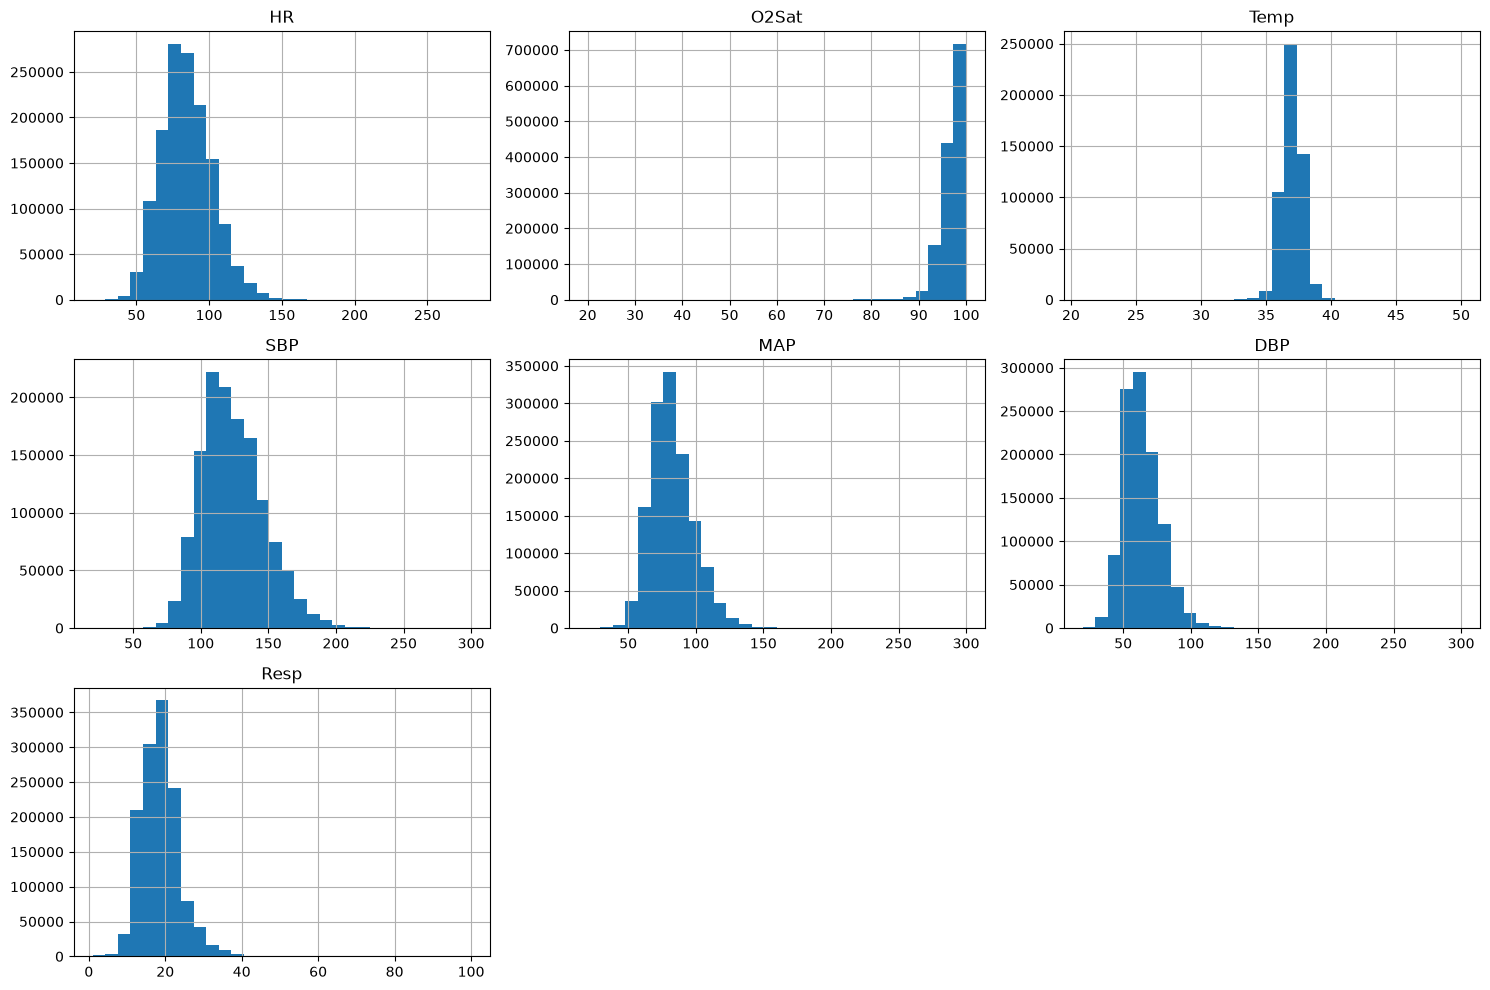

In [30]:
vital_signs = [
    'HR',
    'O2Sat',
    'Temp',
    'SBP',
    'MAP',
    'DBP',
    'Resp'
]

df[vital_signs].hist(
    bins=30,
    figsize=(15, 10)
)

plt.tight_layout()
plt.show()

___

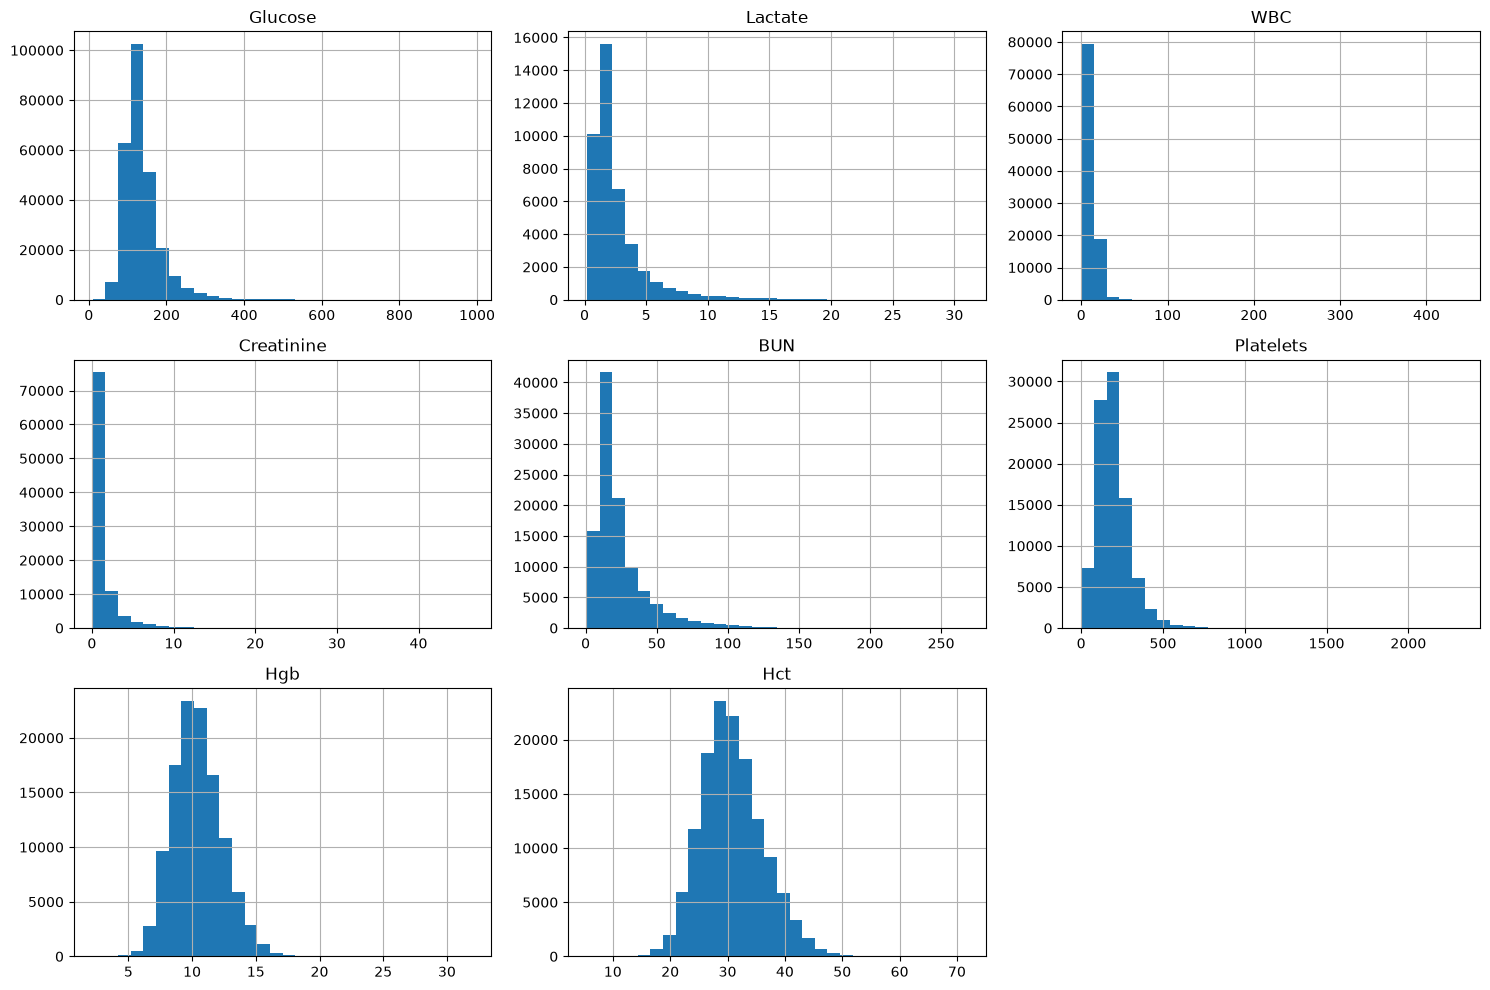

In [31]:
lab_features = [
    'Glucose',
    'Lactate',
    'WBC',
    'Creatinine',
    'BUN',
    'Platelets',
    'Hgb',
    'Hct'
]

df[lab_features].hist(
    bins=30,
    figsize=(15, 10)
)

plt.tight_layout()
plt.show()

___

### Numerical Feature Analysis Findings

The distribution analysis provides the following observations:

#### Vital Signs

- **HR (Heart Rate):** Most observations are concentrated around 60–100 bpm, with a wider range extending to higher values.
- **O2Sat (Oxygen Saturation):** Values are strongly concentrated toward the upper end of the scale, mostly around 90–100%.
- **Temp (Temperature):** Most observations are concentrated around approximately 36–38°C, with a peak near 37°C.
- **SBP (Systolic Blood Pressure):** Most observations are concentrated within approximately 80–180 mmHg.
- **MAP (Mean Arterial Pressure):** Most observations are concentrated around approximately 60–120 mmHg.
- **DBP (Diastolic Blood Pressure):** Most observations are concentrated around approximately 40–100 mmHg.
- **Resp (Respiratory Rate):** Most observations are concentrated around approximately 10–30 breaths per minute.

#### Laboratory Features

- **Glucose:** The distribution is right-skewed, with most observations concentrated at lower values and a tail toward higher values.
- **Lactate:** Most observations are concentrated around lower values, with a right-skewed distribution.
- **WBC:** Most observations are concentrated at lower-to-moderate values, with a long upper tail.
- **Creatinine:** The distribution is right-skewed, with most observations concentrated at lower values.
- **BUN:** Most observations are concentrated at lower values, with a tail extending toward higher values.
- **Platelets:** Most observations are concentrated within a lower-to-moderate range, with some observations extending to higher values.
- **Hgb (Hemoglobin):** Most observations are concentrated approximately between 8–16 g/dL.
- **Hct (Hematocrit):** Most observations are concentrated approximately between 30–40%.

### Overall Observation

Several laboratory features show noticeable right-skewness and long tails. The numerical features also have substantially different numbers of available observations because of missing clinical measurements.

These observations will be considered during data preprocessing and model development. Potential extreme values will be investigated separately during the outlier analysis.

___
___

# 9. Outlier Analysis

In [32]:
outlier_features = [
    'HR',
    'O2Sat',
    'Temp',
    'SBP',
    'MAP',
    'DBP',
    'Resp',
    'Glucose',
    'Lactate',
    'WBC',
    'Creatinine',
    'BUN',
    'Platelets',
    'Hgb',
    'Hct'
]

In [33]:
outlier_summary = []

for col in outlier_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ][col].count()
    
    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outliers,
        'Outlier Percentage': (outliers / df[col].notna().sum()) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,HR,72.00,95.50,23.50,36.750,130.750,14032,1.003138
1,O2Sat,96.00,99.50,3.50,90.750,104.750,24782,1.836419
2,Temp,36.50,37.50,1.00,35.000,39.000,6569,1.250700
3,SBP,107.00,138.00,31.00,60.500,184.500,15842,1.194771
4,MAP,71.00,92.00,21.00,39.500,123.500,21894,1.611109
5,DBP,54.00,72.00,18.00,27.000,99.000,16296,1.529199
6,Resp,15.00,21.50,6.50,5.250,31.250,27855,2.120065
7,Glucose,106.00,153.00,47.00,35.500,223.500,14948,5.629793
8,Lactate,1.26,3.00,1.74,-1.350,5.610,3529,8.514694
9,WBC,7.60,13.80,6.20,-1.700,23.100,3475,3.494324


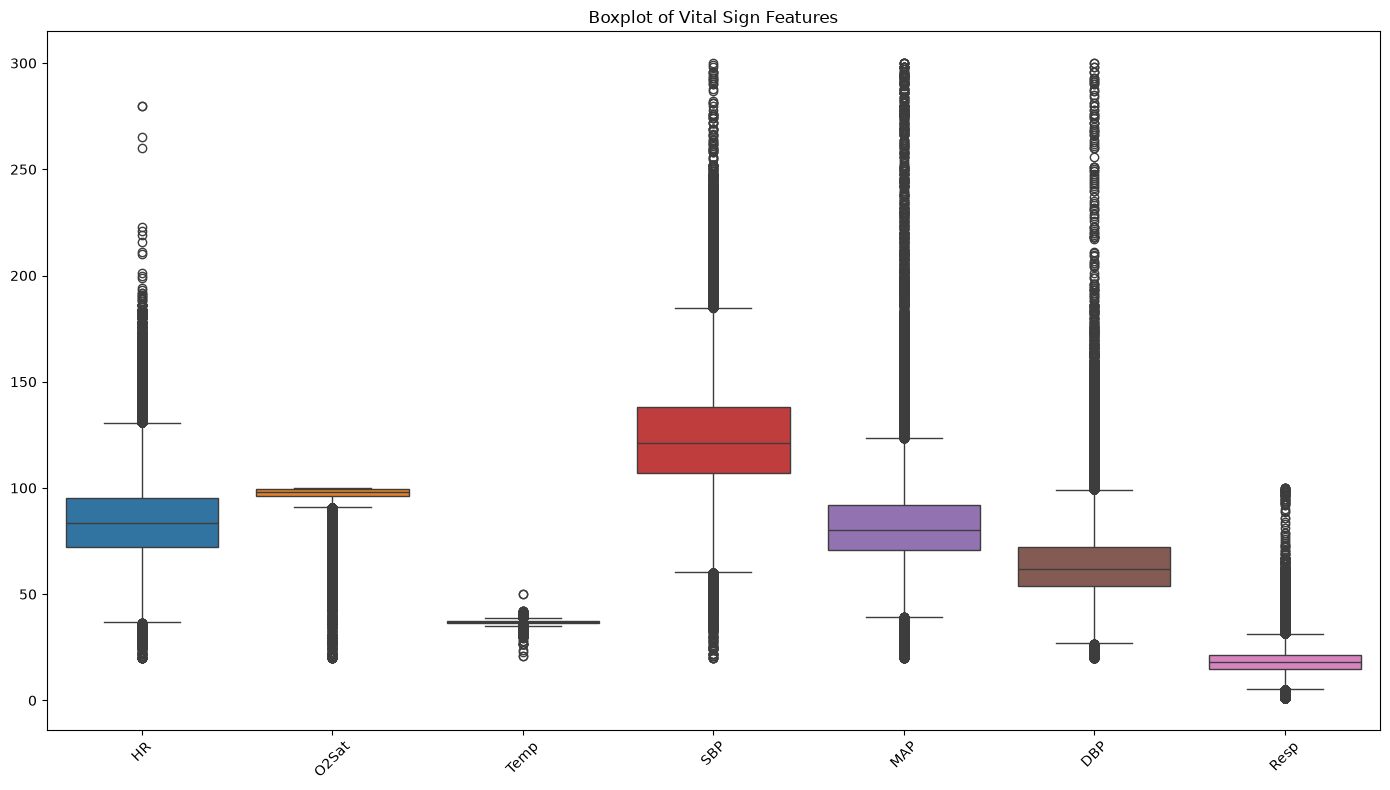

In [35]:
vital_outlier_features = [
    'HR',
    'O2Sat',
    'Temp',
    'SBP',
    'MAP',
    'DBP',
    'Resp'
]

plt.figure(figsize=(14, 8))

sns.boxplot(data=df[vital_outlier_features])

plt.title('Boxplot of Vital Sign Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

___

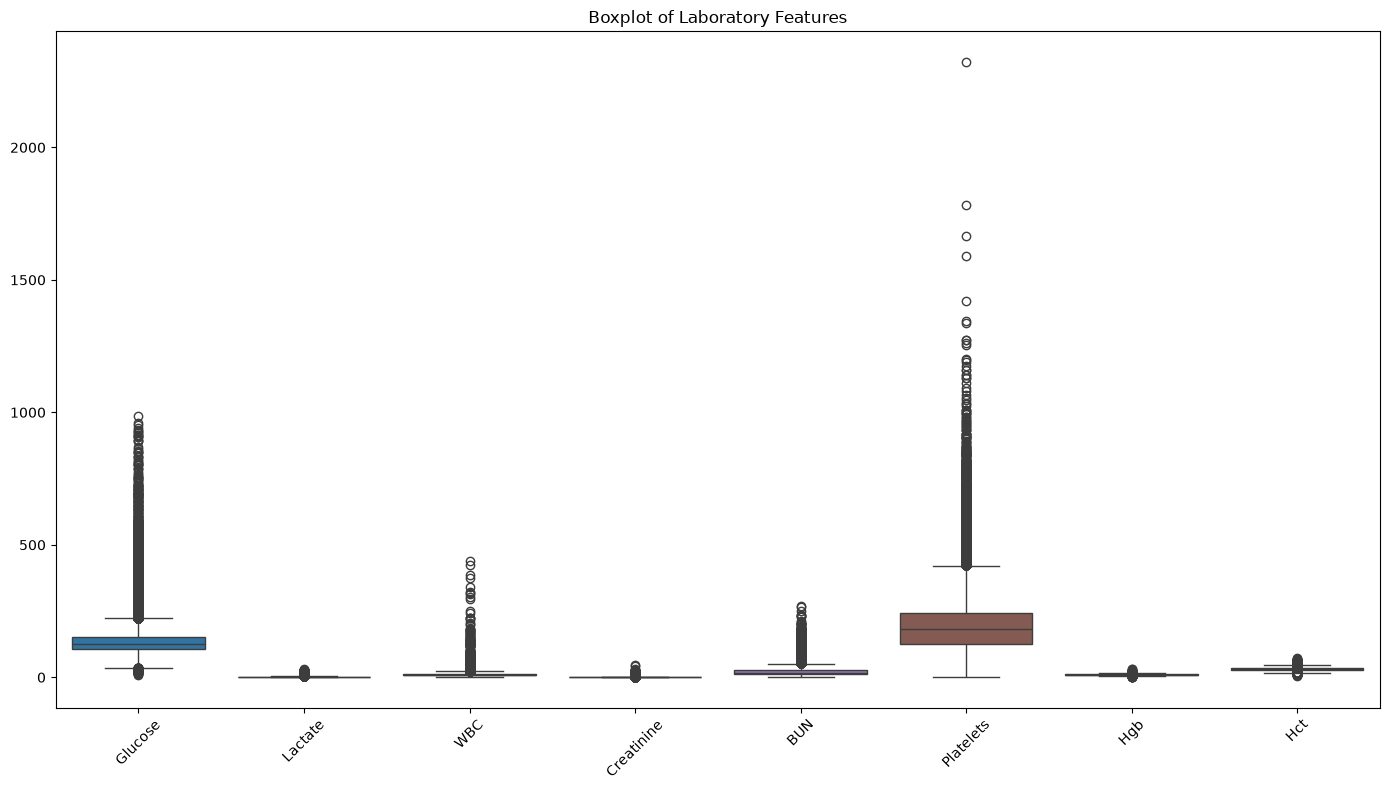

In [36]:
lab_outlier_features = [
    'Glucose',
    'Lactate',
    'WBC',
    'Creatinine',
    'BUN',
    'Platelets',
    'Hgb',
    'Hct'
]

plt.figure(figsize=(14, 8))

sns.boxplot(data=df[lab_outlier_features])

plt.title('Boxplot of Laboratory Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

___

### Outlier Analysis Findings

The boxplots provide a visual summary of the distributions and potential extreme observations in the selected vital-sign and laboratory features.

#### Vital Sign Features

- **HR (Heart Rate):** The distribution is centered around approximately 70–80 bpm, with observations extending toward higher values.
- **O2Sat (Oxygen Saturation):** Values are strongly concentrated near the upper end of the scale, with some observations at lower levels.
- **Temp (Temperature):** Most observations are concentrated around approximately 36.5–37.5°C, with some values extending beyond this range.
- **SBP, MAP, and DBP:** The blood pressure measurements show moderate variability, with observations extending beyond the central ranges.
- **Resp (Respiratory Rate):** Most observations are concentrated around lower-to-moderate respiratory rates, with some higher values.

#### Laboratory Features

- **Glucose:** The distribution shows a concentration of observations at lower-to-moderate values, with a noticeable upper tail.
- **Lactate:** Most observations are concentrated at lower values, with some higher observations.
- **WBC:** The distribution is concentrated at lower-to-moderate values with observations extending toward higher values.
- **Creatinine:** The feature shows a pronounced right-skewed distribution with a substantial upper tail.
- **BUN:** BUN also shows right-skewness, with observations extending to considerably higher values.
- **Platelets:** Most observations are concentrated within a central range, with some higher and lower observations.
- **Hgb and Hct:** Both features show relatively concentrated distributions with some observations outside the central ranges.

### Overall Observation

The boxplots confirm the presence of potential extreme observations across several features. This is consistent with the IQR-based analysis, where features such as Creatinine, Lactate, BUN, and Glucose had relatively higher proportions of observations beyond the IQR boundaries.

These extreme observations are not automatically considered erroneous. They may represent genuine variation in patient measurements. Therefore, no observations are removed during EDA. Any treatment of extreme values will be considered during the data preprocessing stage.

___
___

# 10. Correlation Analysis

In [37]:
correlation_matrix = df[clinical_numeric_cols].corr()

correlation_matrix

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age
HR,1.000000,-0.075651,0.258901,-0.033710,0.069777,0.129359,0.225994,0.022541,-0.091367,-0.092121,...,0.011283,0.020794,0.004661,-0.080780,-0.080519,0.010539,0.132349,0.075185,0.026032,-0.157255
O2Sat,-0.075651,1.000000,-0.030200,0.024909,0.025553,0.000781,-0.147493,-0.000717,0.032439,-0.060749,...,-0.023149,-0.016952,-0.003145,-0.118928,-0.102113,-0.072531,-0.026618,-0.074449,-0.024119,-0.049195
Temp,0.258901,-0.030200,1.000000,0.002297,-0.062543,-0.106308,0.120913,0.189782,0.148492,0.079276,...,0.053308,-0.025180,0.014465,-0.042781,-0.034831,-0.113904,0.037158,0.255690,0.000458,-0.070971
SBP,-0.033710,0.024909,0.002297,1.000000,0.780469,0.539739,0.045887,0.089038,0.151232,0.058078,...,-0.095344,-0.029644,-0.104515,0.094496,0.075699,-0.102243,-0.038851,0.049514,0.026491,0.024524
MAP,0.069777,0.025553,-0.062543,0.780469,1.000000,0.852315,0.049081,0.082885,0.111239,0.022242,...,-0.096383,-0.038740,-0.051024,0.177813,0.149366,-0.066753,-0.045214,0.048653,0.045086,-0.148738
DBP,0.129359,0.000781,-0.106308,0.539739,0.852315,1.000000,0.061883,0.070692,0.080085,0.023649,...,-0.094669,-0.029197,-0.012079,0.236447,0.208688,-0.046170,-0.052250,0.043012,0.087190,-0.265540
Resp,0.225994,-0.147493,0.120913,0.045887,0.049081,0.061883,1.000000,-0.159129,-0.033947,-0.041246,...,0.009578,0.012379,0.011235,0.019695,0.002802,0.059922,0.043930,0.112186,0.066271,0.032597
EtCO2,0.022541,-0.000717,0.189782,0.089038,0.082885,0.070692,-0.159129,1.000000,0.163442,0.287963,...,-0.042817,-0.126207,-0.008238,0.102066,0.070072,-0.180418,-0.023125,0.167812,0.176532,-0.176406
BaseExcess,-0.091367,0.032439,0.148492,0.151232,0.111239,0.080085,-0.033947,0.163442,1.000000,0.856930,...,-0.232639,0.043625,0.022171,-0.049356,-0.033302,-0.231371,-0.165710,0.123766,0.079221,-0.041594
HCO3,-0.092121,-0.060749,0.079276,0.058078,0.022242,0.023649,-0.041246,0.287963,0.856930,1.000000,...,-0.155256,-0.087496,-0.103888,0.048258,0.026371,-0.130943,-0.117264,0.098305,0.092842,0.020913


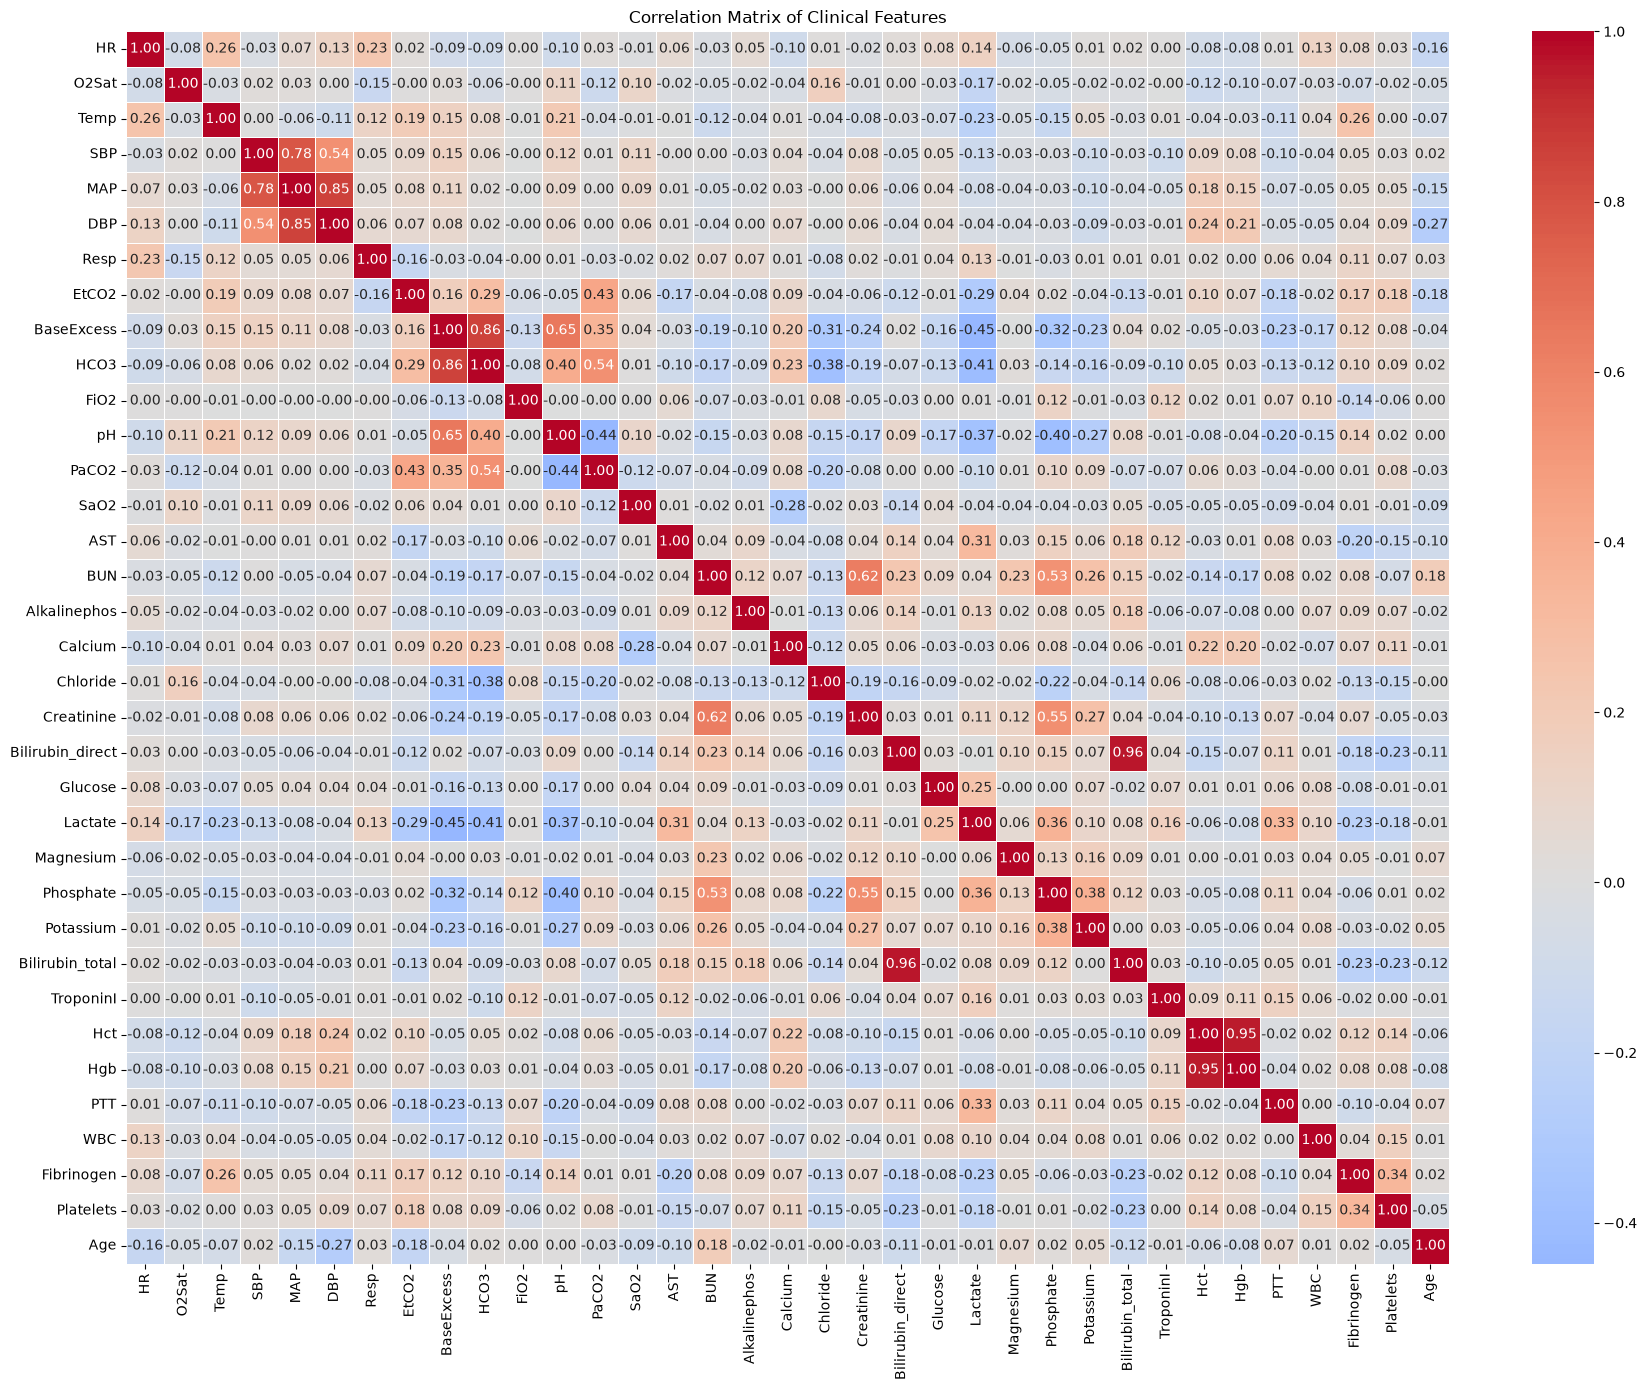

In [39]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot = True,
    fmt= ".2f"
)

plt.title('Correlation Matrix of Clinical Features')
plt.tight_layout()
plt.show()

___

The heatmap is extremely large and difficult to understand. Thus we make correlated pairs and sort values to obtain positive correlated and negative correlated pairs.

___

In [41]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(15)

Bilirubin_direct  Bilirubin_total    0.963987
Hct               Hgb                0.952208
BaseExcess        HCO3               0.856930
MAP               DBP                0.852315
SBP               MAP                0.780469
BaseExcess        pH                 0.650621
BUN               Creatinine         0.623934
Creatinine        Phosphate          0.548615
SBP               DBP                0.539739
HCO3              PaCO2              0.538653
BUN               Phosphate          0.534115
EtCO2             PaCO2              0.430414
HCO3              pH                 0.400755
Phosphate         Potassium          0.379061
Lactate           Phosphate          0.361412
dtype: float64

In [45]:
# Get the correlation matrix
correlation_matrix = df[clinical_numeric_cols].corr()

# Select only the lower triangle to avoid duplicate pairs
mask = np.tril(np.ones(correlation_matrix.shape), k=-1).astype(bool)

negative_corr = (
    correlation_matrix.where(mask)
    .stack()
    .sort_values()
)

negative_corr.head(15)

Lactate     BaseExcess         -0.447899
PaCO2       pH                 -0.436862
Lactate     HCO3               -0.406001
Phosphate   pH                 -0.395798
Chloride    HCO3               -0.384768
Lactate     pH                 -0.369764
Phosphate   BaseExcess         -0.320600
Chloride    BaseExcess         -0.314160
Lactate     EtCO2              -0.294803
Calcium     SaO2               -0.277224
Potassium   pH                 -0.272470
Age         DBP                -0.265540
Creatinine  BaseExcess         -0.235374
Platelets   Bilirubin_direct   -0.233655
Potassium   BaseExcess         -0.232639
dtype: float64

___

### Correlation Analysis Findings

The correlation analysis identified several notable relationships among the clinical and laboratory features.

The strongest positive correlations observed were:

- **Bilirubin_direct and Bilirubin_total:** 0.964
- **Hct and Hgb:** 0.952
- **BaseExcess and HCO3:** 0.857
- **MAP and DBP:** 0.852
- **SBP and MAP:** 0.780
- **BaseExcess and pH:** 0.651
- **BUN and Creatinine:** 0.624
- **Creatinine and Phosphate:** 0.549
- **SBP and DBP:** 0.540
- **HCO3 and PaCO2:** 0.538

These correlations indicate that some clinical variables contain similar or related information. For example, the strong correlation between SBP and MAP, and between MAP and DBP, is expected because these measurements describe different aspects of blood pressure.

Similarly, the strong correlation between Hct and Hgb indicates a close relationship between these two blood-related measurements.

The high correlation between Bilirubin_direct and Bilirubin_total and between BaseExcess and HCO3 suggests potential redundancy among some laboratory features.


---

#### Negative Correlations

Several negative correlations were also identified among the clinical features.

The strongest negative relationships included:

- **Lactate and BaseExcess:** -0.448
- **PaCO2 and pH:** -0.437
- **Lactate and HCO3:** -0.406
- **Phosphate and pH:** -0.396
- **Chloride and HCO3:** -0.385
- **Lactate and pH:** -0.370
- **Phosphate and BaseExcess:** -0.321
- **Chloride and BaseExcess:** -0.314
- **Lactate and EtCO2:** -0.295
- **Calcium and SaO2:** -0.277

The strongest negative correlation was observed between Lactate and BaseExcess (-0.448), followed by PaCO2 and pH (-0.437).

These relationships indicate that some clinical variables tend to move in opposite directions. However, correlation measures association rather than causation, and the relationships may also be influenced by the clinical context and missing observations.

Correlated features are not removed during EDA. Their usefulness and potential redundancy will be considered during feature selection and model development.

___
___

# 11. Features and Target Analysis

In [46]:
sepsis_features = [
    'HR',
    'O2Sat',
    'Temp',
    'SBP',
    'MAP',
    'DBP',
    'Resp',
    'Glucose',
    'Lactate',
    'WBC',
    'Creatinine',
    'BUN'
]

In [47]:
sepsis_group_stats = df.groupby('SepsisLabel')[sepsis_features].median().T

sepsis_group_stats

SepsisLabel,0,1
HR,83.00,90.0
O2Sat,98.00,98.0
Temp,37.00,37.3
SBP,121.00,118.0
MAP,80.00,78.0
DBP,62.00,60.0
Resp,18.00,20.0
Glucose,126.50,129.0
Lactate,1.80,1.7
WBC,10.30,11.8


___

### Feature vs Sepsis Findings

The comparison of median clinical measurements between non-sepsis (`SepsisLabel = 0`) and sepsis (`SepsisLabel = 1`) observations shows several differences.

- Heart rate is higher in sepsis-labeled observations.
- Respiratory rate is higher in sepsis-labeled observations.
- WBC count is higher in sepsis-labeled observations.
- Creatinine and BUN show higher median values in sepsis-labeled observations.
- Systolic, mean arterial, and diastolic blood pressure show slightly lower median values in sepsis-labeled observations.
- Oxygen saturation shows similar median values between the two groups.
- Temperature and glucose show relatively small differences.
- Lactate has similar median values between the two groups in this comparison.

These differences provide useful exploratory insights into the dataset. However, median comparisons alone are not sufficient to determine predictive importance. Feature importance and model-based evaluation will be performed during the modeling stage.

___

In [48]:
df.groupby('SepsisLabel')[sepsis_features].mean().T

SepsisLabel,0,1
HR,84.465334,90.785245
O2Sat,97.197724,96.994425
Temp,36.972202,37.250813
SBP,123.792359,121.445982
MAP,82.442375,80.168490
DBP,63.864454,62.018848
Resp,18.694357,20.460376
Glucose,136.871742,140.029218
Lactate,2.642708,2.726364
WBC,11.401411,13.325927


___

### Mean Comparison Findings

The mean values of selected clinical features were compared between non-sepsis (`SepsisLabel = 0`) and sepsis (`SepsisLabel = 1`) observations.

The sepsis-labeled observations show higher mean values for heart rate, respiratory rate, temperature, WBC, creatinine, BUN, glucose, and lactate. In contrast, the mean SBP, MAP, and DBP values are slightly lower in the sepsis group.

Oxygen saturation shows very similar mean values between the two groups.

The mean and median comparisons show broadly consistent patterns, particularly for heart rate, respiratory rate, WBC, creatinine, and BUN. Some laboratory variables have means considerably higher than their medians, which is consistent with the right-skewed distributions observed during numerical feature analysis.

These comparisons describe differences between the groups but do not establish causation or determine predictive importance.

___

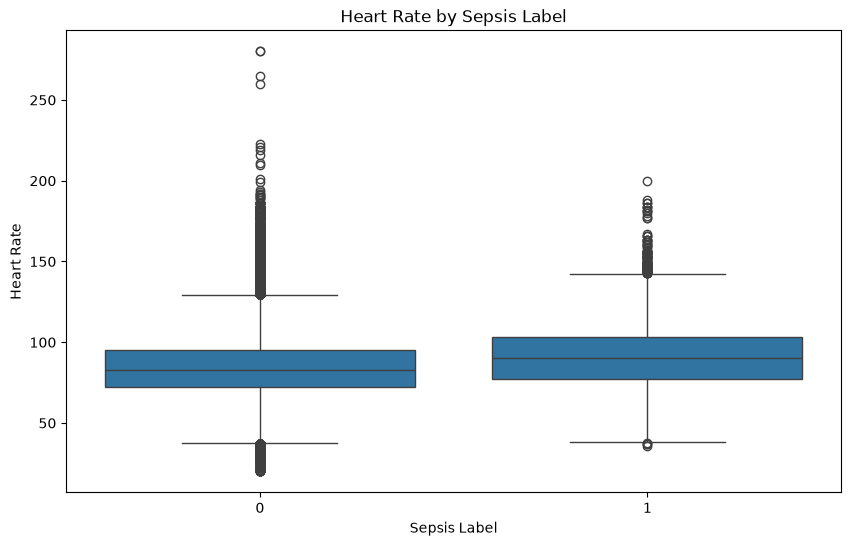

In [49]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='SepsisLabel',
    y='HR'
)

plt.title('Heart Rate by Sepsis Label')
plt.xlabel('Sepsis Label')
plt.ylabel('Heart Rate')
plt.show()

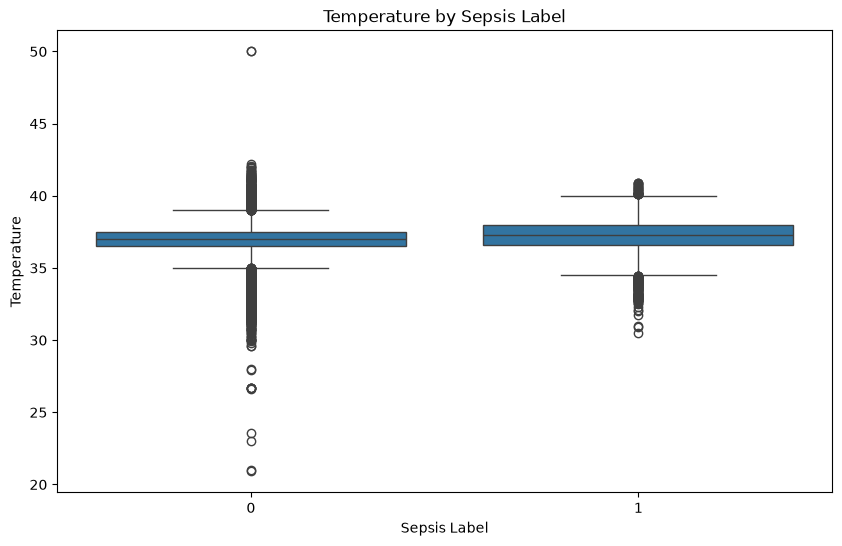

In [50]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='SepsisLabel',
    y='Temp'
)

plt.title('Temperature by Sepsis Label')
plt.xlabel('Sepsis Label')
plt.ylabel('Temperature')
plt.show()

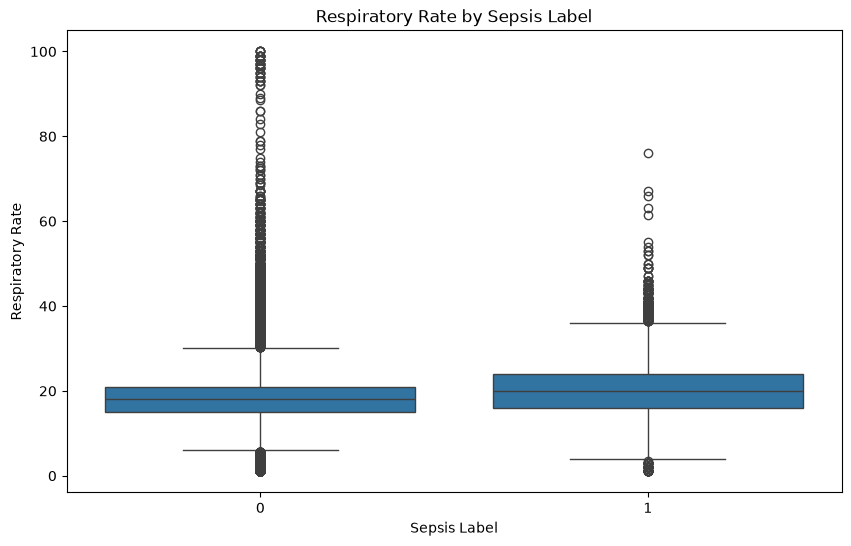

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='SepsisLabel',
    y='Resp'
)

plt.title('Respiratory Rate by Sepsis Label')
plt.xlabel('Sepsis Label')
plt.ylabel('Respiratory Rate')
plt.show()

___

### Boxplot Findings

Boxplots were used to compare the distributions of heart rate, temperature, and respiratory rate between non-sepsis (`SepsisLabel = 0`) and sepsis (`SepsisLabel = 1`) observations.

#### Heart Rate

- Both groups have similar median heart rates, with the sepsis group showing a somewhat higher central tendency.
- The interquartile ranges overlap considerably, indicating substantial similarity in the distributions.
- Higher heart-rate observations and outliers are present in both groups.
- The presence of overlapping distributions suggests that heart rate alone may not clearly distinguish between sepsis and non-sepsis observations.

#### Temperature

- The median temperatures of the two groups are close to each other.
- The sepsis group has a slightly higher median and mean temperature.
- The distributions show considerable overlap between the two groups.
- Higher-temperature observations are present in both groups, although some elevated values occur among sepsis-labeled observations.
- Temperature alone does not show a clear separation between the two target groups.

#### Respiratory Rate

- Both groups have similar median respiratory rates, although the sepsis group has a slightly higher mean and median.
- The interquartile ranges overlap substantially.
- Higher respiratory-rate observations and outliers occur in both groups.
- The sepsis group shows somewhat more elevated respiratory-rate observations, but respiratory rate alone does not clearly separate the two groups.

### Overall Observation

The boxplots show substantial overlap between sepsis and non-sepsis observations for heart rate, temperature, and respiratory rate.

Although the sepsis group tends to show slightly higher values for these features, the distributions are not clearly separated. Therefore, these variables are unlikely to provide a complete distinction between the two groups individually. Their predictive value should be evaluated together with other clinical and laboratory features during model development.

___
---

# 12. Time Feature Analysis

In [52]:
print("Minimum Hour:", df['Hour'].min())
print("Maximum Hour:", df['Hour'].max())

print("Minimum ICULOS:", df['ICULOS'].min())
print("Maximum ICULOS:", df['ICULOS'].max())

Minimum Hour: 0
Maximum Hour: 335
Minimum ICULOS: 1
Maximum ICULOS: 336


In [53]:
df[['Hour', 'ICULOS']].describe()

,Hour,ICULOS
count,1.552210e+06,1.552210e+06
mean,2.549274e+01,2.699499e+01
std,2.888256e+01,2.900542e+01
min,0.000000e+00,1.000000e+00
25%,9.000000e+00,1.100000e+01
50%,1.900000e+01,2.100000e+01
75%,3.300000e+01,3.400000e+01
max,3.350000e+02,3.360000e+02


___

### Time Feature Findings

The temporal features `Hour` and `ICULOS` were examined to understand the duration and progression of ICU observations.

- `Hour` ranges from 0 to 335 hours.
- `ICULOS` ranges from 1 to 336 hours.
- The mean values are approximately 25.49 hours for `Hour` and 26.99 hours for `ICULOS`.
- The median values are 19 hours for `Hour` and 21 hours for `ICULOS`.
- The maximum values indicate that the dataset contains patients with substantially longer ICU stays than the typical observation period.

Overall, the dataset contains observations across a wide range of ICU stay durations. Therefore, temporal information may be relevant when analyzing the progression of sepsis-related observations.

___

### Analysis by ICU Hour

In [54]:
hour_counts = df['Hour'].value_counts().sort_index()

hour_counts.head(20)

Hour
0     40336
1     40336
2     40336
3     40336
4     40336
5     40336
6     40336
7     40336
8     40008
9     39772
10    39551
11    39317
12    39032
13    38682
14    38270
15    37734
16    37133
17    36412
18    35569
19    34665
Name: count, dtype: int64

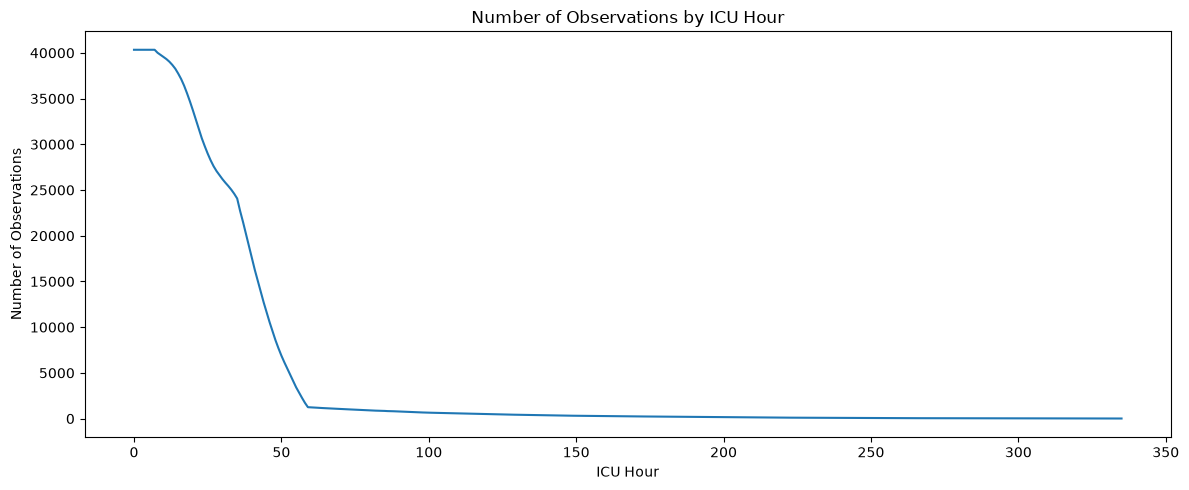

In [55]:
plt.figure(figsize=(12,5))

plt.plot(hour_counts.index, hour_counts.values)

plt.xlabel("ICU Hour")
plt.ylabel("Number of Observations")
plt.title("Number of Observations by ICU Hour")

plt.tight_layout()
plt.show()

___

###  Observations by ICU Hour

The number of observations at each ICU hour was examined to understand how the dataset is distributed over time.

- Hours 0 through 7 contain observations from all 40,336 patients.
- The number of observations begins to decrease from hour 8 onward.
- By hour 19, the number of observations has decreased to 34,665.
- The number of observations continues to decline as ICU hour increases.

This pattern is expected because patients have different ICU stay durations. Patients with shorter ICU stays do not contribute observations to later ICU hours.

Therefore, the decreasing number of observations over time should be considered when interpreting time-based patterns, particularly at later ICU hours where the number of available observations is smaller.
___

###  Sepsis Cases Over Time

In [56]:
sepsis_by_hour = df.groupby('Hour')['SepsisLabel'].sum()

sepsis_by_hour.head(20)

Hour
0     426
1     502
2     569
3     615
4     668
5     733
6     778
7     828
8     635
9     551
10    502
11    476
12    456
13    452
14    420
15    404
16    386
17    363
18    347
19    345
Name: SepsisLabel, dtype: int64

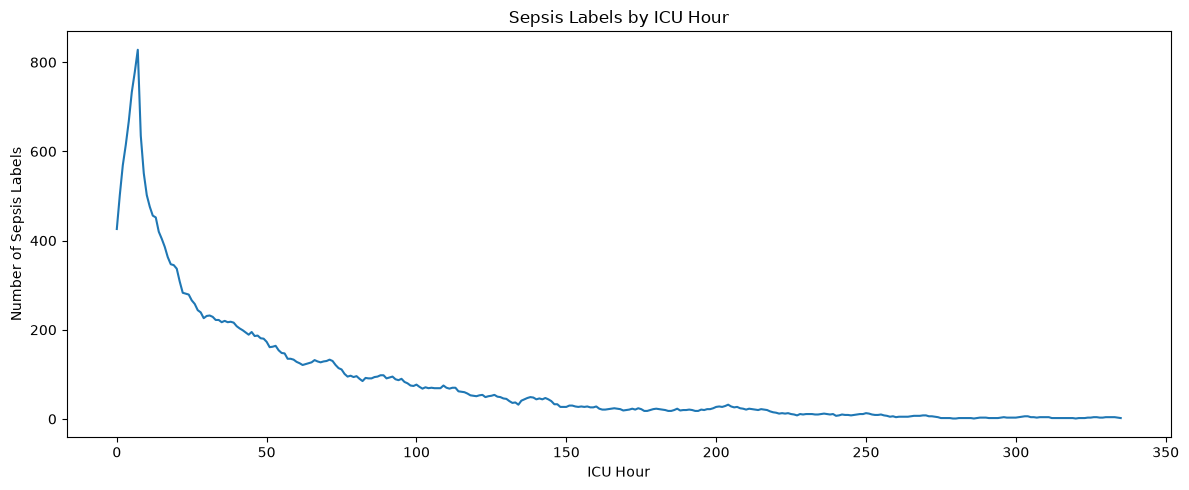

In [57]:
plt.figure(figsize=(12,5))

plt.plot(sepsis_by_hour.index, sepsis_by_hour.values)

plt.xlabel("ICU Hour")
plt.ylabel("Number of Sepsis Labels")
plt.title("Sepsis Labels by ICU Hour")

plt.tight_layout()
plt.show()

___

###  Sepsis Cases Over Time Description

The number of sepsis-labeled observations was examined across ICU hours.

- The number of sepsis labels increases from 426 observations at hour 0 to 828 observations at hour 7.
- Hour 7 has the highest number of sepsis-labeled observations among the first 20 ICU hours examined.
- After hour 7, the number of sepsis labels decreases progressively.
- By hour 19, the number of sepsis-labeled observations has decreased to 345.
- The number of sepsis labels continues to decrease at later ICU hours.

The decline in later hours should be interpreted together with the decreasing number of total observations over time. Since fewer patients contribute observations at later ICU hours, raw sepsis counts alone do not indicate that sepsis occurrence necessarily decreases over time.

Therefore, sepsis rate by ICU hour will provide a more informative comparison by accounting for the total number of observations at each hour.

---


### Analysis of Sepsis over ICU hours

In [58]:
sepsis_rate_by_hour = df.groupby('Hour')['SepsisLabel'].mean() * 100

sepsis_rate_by_hour.head(20)

Hour
0     1.056129
1     1.244546
2     1.410651
3     1.524693
4     1.656089
5     1.817235
6     1.928798
7     2.052757
8     1.587183
9     1.385397
10    1.269247
11    1.210672
12    1.168272
13    1.168502
14    1.097465
15    1.070652
16    1.039507
17    0.996924
18    0.975569
19    0.995240
Name: SepsisLabel, dtype: float64

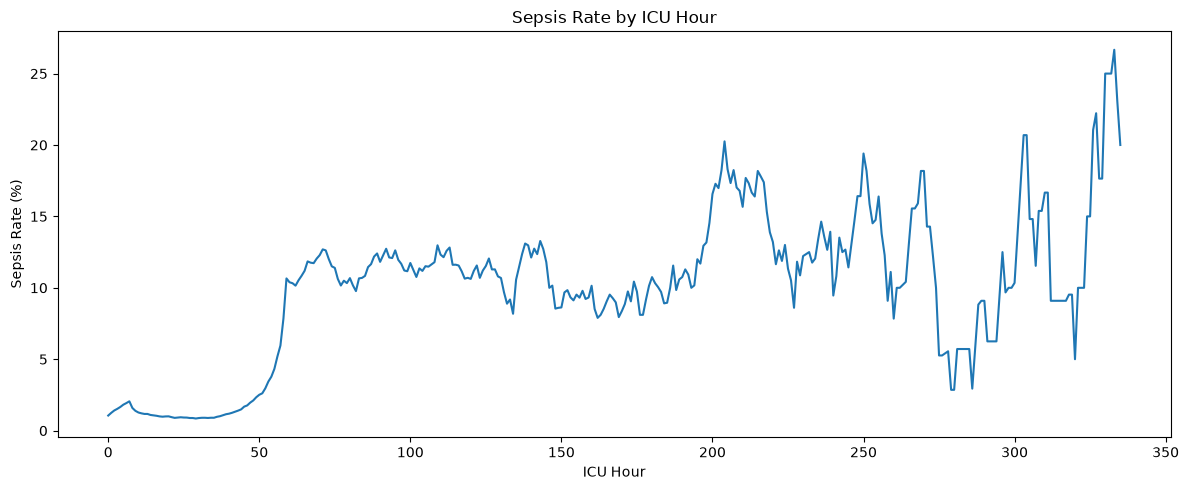

In [59]:
plt.figure(figsize=(12,5))

plt.plot(sepsis_rate_by_hour.index, sepsis_rate_by_hour.values)

plt.xlabel("ICU Hour")
plt.ylabel("Sepsis Rate (%)")
plt.title("Sepsis Rate by ICU Hour")

plt.tight_layout()
plt.show()

### Sepsis Rate by ICU Hour Description

The sepsis rate was calculated for each ICU hour by dividing the number of sepsis-labeled observations by the total number of observations at that hour.

During the first 20 ICU hours, the sepsis rate ranges approximately from 1.0% to 2.1%. The highest rate in this period occurs around hour 7 at approximately 2.05%.

The sepsis rate varies across ICU hours. However, the number of observations decreases substantially at later ICU hours, so rates at those hours should be interpreted cautiously because they may be based on fewer observations.

Overall, the analysis indicates that sepsis labels are distributed across different stages of the ICU stay, while the changing number of observations over time should be considered when interpreting temporal patterns.

In [60]:
time_summary = pd.DataFrame({
    'Total_Observations': df.groupby('Hour').size(),
    'Sepsis_Labels': df.groupby('Hour')['SepsisLabel'].sum(),
    'Sepsis_Rate': df.groupby('Hour')['SepsisLabel'].mean() * 100
})

time_summary.loc[45:60]

,Total_Observations,Sepsis_Labels,Sepsis_Rate
Hour,,,
45,11608,195,1.679876
46,10542,186,1.764371
47,9538,187,1.960579
48,8570,181,2.112019
49,7699,180,2.337966
50,6889,173,2.511250
51,6160,161,2.613636
52,5469,162,2.962150
53,4776,164,3.433836


___
### Sepsis Rate by ICU Hour

The sepsis rate was examined across ICU hours to account for the changing number of observations over time.

A noticeable increase in the observed sepsis rate occurs after approximately 50 ICU hours. For example, the sepsis rate increases from approximately 1.68% at hour 45 to 2.51% at hour 50 and reaches approximately 10.66% at hour 59.

However, the number of observations decreases substantially over the same period. Total observations decrease from 11,608 at hour 45 to 1,248 at hour 59.

Therefore, the increase in sepsis rate at later ICU hours should be interpreted cautiously. It may reflect the changing composition of the patients who remain in the ICU for longer periods, rather than indicating that ICU time itself causes an increased risk of sepsis.

This analysis demonstrates that the dataset has an important temporal structure that should be considered during model development.
___

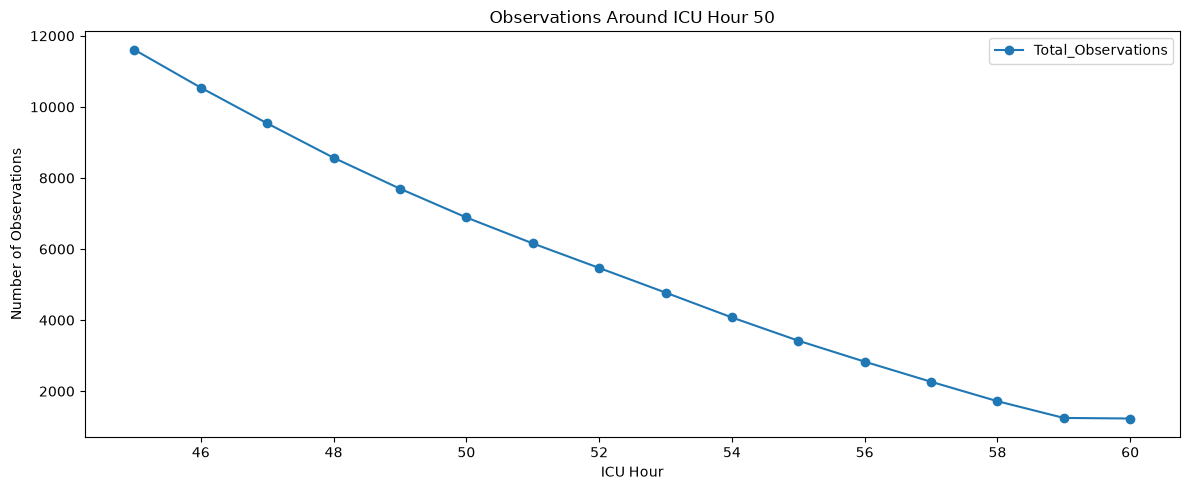

In [61]:
time_summary.loc[45:60].plot(
    y='Total_Observations',
    figsize=(12,5),
    marker='o'
)

plt.title("Observations Around ICU Hour 50")
plt.xlabel("ICU Hour")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

___
The number of observations was examined around ICU hours 45 to 60 to understand how the dataset changes at later ICU hours.

- At hour 45, there are approximately 11,608 observations.
- The number of observations decreases steadily as ICU hour increases.
- By hour 60, the number of observations has decreased to approximately 1,232.
- This represents a substantial reduction in the number of available observations over this period.

The decreasing number of observations is expected because patients have different ICU stay durations. Patients with shorter ICU stays do not contribute observations to later ICU hours.

Therefore, the decline does not necessarily indicate that measurements are being recorded less frequently. Instead, it mainly reflects the decreasing number of patients who remain in the ICU at later hours.
___
___

# 13. EDA Findings

The exploratory data analysis provided an overall understanding of the dataset, its structure, data quality, target variable, clinical features, and temporal characteristics.

### Key Findings

1. **Dataset Structure**
   - The dataset contains 1,552,210 observations and 43 columns.
   - There are 40,336 unique patients.
   - Each patient can have multiple observations across different ICU hours.

2. **Missing Values**
   - Many clinical laboratory features contain a large proportion of missing values.
   - Some features have relatively few missing values, while others have more than 90% missing values.
   - Missing values will therefore require careful handling during preprocessing.

3. **Duplicate Records**
   - No duplicate rows were identified in the dataset.

4. **Target Variable**
   - The target variable is `SepsisLabel`.
   - Approximately 98.20% of observations are labeled as non-sepsis and 1.80% as sepsis.
   - This indicates a significant class imbalance that must be considered during model development.

5. **Patient-Level Structure**
   - Multiple observations belong to the same patient.
   - Therefore, observations from the same patient should not be randomly distributed between training and testing datasets.
   - Patient-level splitting will be considered during model development to reduce data leakage.

6. **Numerical Features**
   - Clinical and laboratory variables have different distributions and scales.
   - Several laboratory features show right-skewed distributions and long tails.
   - These characteristics will be considered during preprocessing and model development.

7. **Outliers**
   - Several features contain observations outside their IQR-based bounds.
   - Features such as creatinine, lactate, BUN, and glucose showed relatively higher proportions of IQR-based outliers.
   - These observations were not removed during EDA because extreme clinical measurements may represent genuine patient observations.

8. **Correlation**
   - Several clinical features show strong relationships with each other.
   - For example, Hct and Hgb, direct and total bilirubin, and MAP and DBP have strong positive correlations.
   - Correlation analysis will be considered when selecting and preparing features for modeling.

9. **Feature vs. Sepsis**
   - Some features show differences between sepsis and non-sepsis observations.
   - The sepsis group generally showed somewhat higher values for variables such as heart rate, respiratory rate, WBC, creatinine, and BUN.
   - However, substantial overlap exists between the two groups, indicating that individual features may not clearly distinguish sepsis observations on their own.

10. **Time-Based Patterns**
    - The dataset contains a strong temporal structure because patients have observations across different ICU hours.
    - The number of observations decreases as ICU hour increases because fewer patients remain in the ICU for longer periods.
    - The observed sepsis rate increases around later ICU hours, but the number of available observations also becomes much smaller.
    - Therefore, later-hour patterns should be interpreted cautiously.

### Overall EDA Conclusion

The EDA shows that this dataset has several important characteristics that will influence the machine learning pipeline, including substantial missing data, class imbalance, repeated observations per patient, skewed distributions, extreme values, correlated features, and temporal structure.

These findings will guide the data preprocessing and model development stages.

___
___